In [1]:
import torch
from torch import nn
from pathlib import Path

In [2]:
class ConvBNAct(nn.Sequential):
	def __init__(
		self,
		in_channels,
		out_channels,
		kernel_size,
		stride=1,
		groups=1
	):
		padding = kernel_size // 2

		super().__init__(
			nn.Conv2d(
				in_channels=in_channels,
				out_channels=out_channels,
				kernel_size=kernel_size,
				stride=stride,
				padding=padding,
				groups=groups,
				bias=False
			),
			nn.BatchNorm2d(
				out_channels,
				eps=0.001,
				momentum=0.01
			),
			nn.SiLU(inplace=True)
		)

class SqueezeExcitation(nn.Module):
	def __init__(self, input_channels, squeeze_channels):
		super().__init__()

		self.avgpool = nn.AdaptiveAvgPool2d(1)

		self.fc1 = nn.Conv2d(
			in_channels=input_channels,
			out_channels=squeeze_channels,
			kernel_size=1
		)

		self.act = nn.SiLU(inplace=True)

		self.fc2 = nn.Conv2d(
			in_channels=squeeze_channels,
			out_channels=input_channels,
			kernel_size=1
		)

		self.scale_act = nn.Sigmoid()

	def forward(self, x):
		scale = self.avgpool(x)
		scale = self.fc1(scale)
		scale = self.act(scale)
		scale = self.fc2(scale)
		scale = self.scale_act(scale)

		return x * scale

class StochasticDepth(nn.Module):
	def __init__(self, p):
		super().__init__()
		self.p = p

	def forward(self, x):
		if not self.training or self.p == 0:
			return x

		survival_rate = 1.0 - self.p

		shape = [x.shape[0]] + [1] * (x.ndim - 1)

		random_tensor = survival_rate + torch.rand(
			shape,
			dtype=x.dtype,
			device=x.device
		)

		binary_tensor = torch.floor(random_tensor)

		return x / survival_rate * binary_tensor

class EfficientNetMBConv(nn.Module):
	def __init__(
		self,
		input_channels,
		output_channels,
		expand_ratio,
		kernel_size,
		stride,
		stochastic_depth_prob=0.0
	):
		super().__init__()

		self.use_residual = (
			stride == 1 and input_channels == output_channels
		)

		expanded_channels = input_channels * expand_ratio

		layers = []

		# 1. Expansion: 1x1 Conv + BN + SiLU
		if expand_ratio != 1:
			layers.append(
				ConvBNAct(
					in_channels=input_channels,
					out_channels=expanded_channels,
					kernel_size=1
				)
			)

		# 2. Depthwise: 3x3 або 5x5 Conv + BN + SiLU
		layers.append(
			ConvBNAct(
				in_channels=expanded_channels,
				out_channels=expanded_channels,
				kernel_size=kernel_size,
				stride=stride,
				groups=expanded_channels
			)
		)

		# 3. Squeeze-and-Excitation
		squeeze_channels = max(1, input_channels // 4)

		layers.append(
			SqueezeExcitation(
				input_channels=expanded_channels,
				squeeze_channels=squeeze_channels
			)
		)

		# 4. Projection: linear 1x1 Conv + BN
		layers.append(
			nn.Conv2d(
				in_channels=expanded_channels,
				out_channels=output_channels,
				kernel_size=1,
				bias=False
			)
		)

		layers.append(
			nn.BatchNorm2d(
				output_channels,
				eps=0.001,
				momentum=0.01
			)
		)

		self.block = nn.Sequential(*layers)

		self.stochastic_depth = StochasticDepth(stochastic_depth_prob)

	def forward(self, x):
		result = self.block(x)

		if self.use_residual:
			result = self.stochastic_depth(result)
			result = result + x

		return result

class ReplicaEffNetB0(nn.Module):
  def __init__(
    self,
    num_classes,
    dropout=0.2,
    stochastic_depth_prob=0.2
  ):
    super().__init__()

    self.features = nn.Sequential(
      # Stage 1
      # Stem, k3x3, 3 -> 32, stride=2, layers=1
      ConvBNAct(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        stride=2
      ),

      # Stage 2
      # MBConv1, k3x3, 32 -> 16, stride=1, layers=1
      EfficientNetMBConv(
        input_channels=32,
        output_channels=16,
        expand_ratio=1,
        kernel_size=3,
        stride=1,
        stochastic_depth_prob=0.0
      ),

      # Stage 3
      # MBConv6, k3x3, 16 -> 24, stride=2, layers=2
      EfficientNetMBConv(
        input_channels=16,
        output_channels=24,
        expand_ratio=6,
        kernel_size=3,
        stride=2,
        stochastic_depth_prob=0.0125
      ),
      EfficientNetMBConv(
        input_channels=24,
        output_channels=24,
        expand_ratio=6,
        kernel_size=3,
        stride=1,
        stochastic_depth_prob=0.025
      ),

      # Stage 4
      # MBConv6, k5x5, 24 -> 40, stride=2, layers=2
      EfficientNetMBConv(
        input_channels=24,
        output_channels=40,
        expand_ratio=6,
        kernel_size=5,
        stride=2,
        stochastic_depth_prob=0.0375
      ),
      EfficientNetMBConv(
        input_channels=40,
        output_channels=40,
        expand_ratio=6,
        kernel_size=5,
        stride=1,
        stochastic_depth_prob=0.05
      ),

      # Stage 5
      # MBConv6, k3x3, 40 -> 80, stride=2, layers=3
      EfficientNetMBConv(
        input_channels=40,
        output_channels=80,
        expand_ratio=6,
        kernel_size=3,
        stride=2,
        stochastic_depth_prob=0.0625
      ),
      EfficientNetMBConv(
        input_channels=80,
        output_channels=80,
        expand_ratio=6,
        kernel_size=3,
        stride=1,
        stochastic_depth_prob=0.075
      ),
      EfficientNetMBConv(
        input_channels=80,
        output_channels=80,
        expand_ratio=6,
        kernel_size=3,
        stride=1,
        stochastic_depth_prob=0.0875
      ),

      # Stage 6
      # MBConv6, k5x5, 80 -> 112, stride=1, layers=3
      EfficientNetMBConv(
        input_channels=80,
        output_channels=112,
        expand_ratio=6,
        kernel_size=5,
        stride=1,
        stochastic_depth_prob=0.1
      ),
      EfficientNetMBConv(
        input_channels=112,
        output_channels=112,
        expand_ratio=6,
        kernel_size=5,
        stride=1,
        stochastic_depth_prob=0.1125
      ),
      EfficientNetMBConv(
        input_channels=112,
        output_channels=112,
        expand_ratio=6,
        kernel_size=5,
        stride=1,
        stochastic_depth_prob=0.125
      ),

      # Stage 7
      # MBConv6, k5x5, 112 -> 192, stride=2, layers=4
      EfficientNetMBConv(
        input_channels=112,
        output_channels=192,
        expand_ratio=6,
        kernel_size=5,
        stride=2,
        stochastic_depth_prob=0.1375
      ),
      EfficientNetMBConv(
        input_channels=192,
        output_channels=192,
        expand_ratio=6,
        kernel_size=5,
        stride=1,
        stochastic_depth_prob=0.15
      ),
      EfficientNetMBConv(
        input_channels=192,
        output_channels=192,
        expand_ratio=6,
        kernel_size=5,
        stride=1,
        stochastic_depth_prob=0.1625
      ),
      EfficientNetMBConv(
        input_channels=192,
        output_channels=192,
        expand_ratio=6,
        kernel_size=5,
        stride=1,
        stochastic_depth_prob=0.175
      ),

      # Stage 8
      # MBConv6, k3x3, 192 -> 320, stride=1, layers=1
      EfficientNetMBConv(
        input_channels=192,
        output_channels=320,
        expand_ratio=6,
        kernel_size=3,
        stride=1,
        stochastic_depth_prob=0.1875
      ),

      # Stage 9
      # Head Conv 1x1 & pooling & FC
			ConvBNAct(
				in_channels=320,
				out_channels=1280,
				kernel_size=1,
				stride=1
			)
    )

    self.avgpool = nn.AdaptiveAvgPool2d(1)

    self.classifier = nn.Sequential(
      nn.Dropout(p=dropout, inplace=True),
      nn.Linear(1280, num_classes)
		)

  def forward(self, x):
    x = self.features(x)
    x = self.avgpool(x)
    x = torch.flatten(x, 1)
    x = self.classifier(x)

    return x

In [3]:
import kagglehub
from pathlib import Path

folderpath = Path(kagglehub.dataset_download("kagglevladkh/imagenet1k-animals-mini-split"))

print("Path to dataset files:", folderpath, type(folderpath))

Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/kagglevladkh/imagenet1k-animals-mini-split/versions/1 <class 'pathlib.PosixPath'>


In [4]:
train_dir = folderpath / "train"
test_dir = folderpath / "test"

print(train_dir, test_dir)

/teamspace/studios/this_studio/.cache/kagglehub/datasets/kagglevladkh/imagenet1k-animals-mini-split/versions/1/train /teamspace/studios/this_studio/.cache/kagglehub/datasets/kagglevladkh/imagenet1k-animals-mini-split/versions/1/test


In [5]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode


normalize = transforms.Normalize(
	mean=[0.485, 0.456, 0.406],
	std=[0.229, 0.224, 0.225]
)

train_transform = transforms.Compose([
	transforms.RandomResizedCrop(
		size=(128, 128),
		scale=(0.75, 1.0),
		ratio=(0.8, 1.25),
		interpolation=InterpolationMode.BICUBIC
	),
	transforms.RandomHorizontalFlip(p=0.5),
	transforms.RandomRotation(degrees=10),
	transforms.ColorJitter(
		brightness=0.15,
		contrast=0.15,
		saturation=0.15
	),
	transforms.ToTensor(),
	normalize
])

test_transform = transforms.Compose([
	transforms.Resize(
		size=144,
		interpolation=InterpolationMode.BICUBIC
	),
	transforms.CenterCrop(size=(128, 128)),
	transforms.ToTensor(),
	normalize
])

In [6]:
v1_train_transform = transforms.Compose([
	transforms.RandomResizedCrop(
		size=(224, 224),
		scale=(0.75, 1.0),
		ratio=(0.8, 1.25),
		interpolation=InterpolationMode.BICUBIC
	),
	transforms.RandomHorizontalFlip(p=0.5),
	transforms.RandomRotation(degrees=10),
	transforms.ColorJitter(
		brightness=0.15,
		contrast=0.15,
		saturation=0.15
	),
	transforms.ToTensor(),
	normalize
])

v1_test_transform = transforms.Compose([
	transforms.Resize(
		size=256,
		interpolation=InterpolationMode.BICUBIC
	),
	transforms.CenterCrop(size=(224, 224)),
	transforms.ToTensor(),
	normalize
])

In [7]:
v2_test_transform = transforms.Compose([
	transforms.Resize(
		size=256,
		interpolation=InterpolationMode.BICUBIC
	),
	transforms.ToTensor(),
	normalize
])

In [8]:
from mlutils.data_setup import create_folder_dataloaders

v1_train_dataloader, v1_test_dataloader, class_names, class_to_idx = create_folder_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    train_transform=v1_train_transform,
    test_transform=v1_test_transform,
    batch_size=32
)

num_classes = len(class_names)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [10]:
model_path = Path("v1_224_continued_best_effnetb0_replica.pth")

state_dict = torch.load(
    model_path, 
    map_location=device
)

model_0 = ReplicaEffNetB0(num_classes=num_classes).to(device)
model_0.load_state_dict(state_dict["model_state_dict"])


<All keys matched successfully>

In [11]:
state_dict.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'results', 'test_loss', 'test_acc'])

In [12]:
state_dict["test_acc"]

0.7479839094046098

In [13]:
from mlutils.visual.predictions import plot_image_prediction

In [14]:
transforms = [test_transform, v1_test_transform, v2_test_transform]

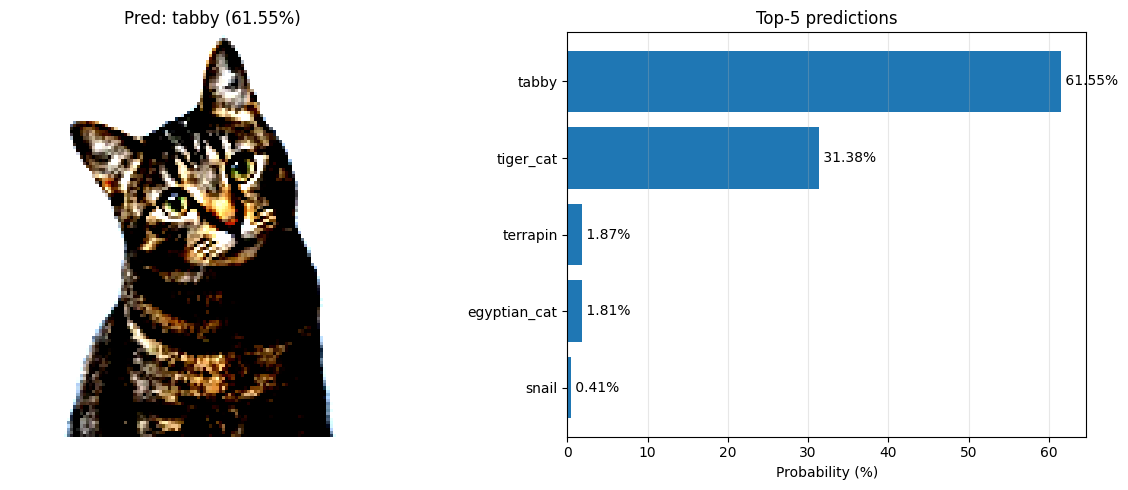

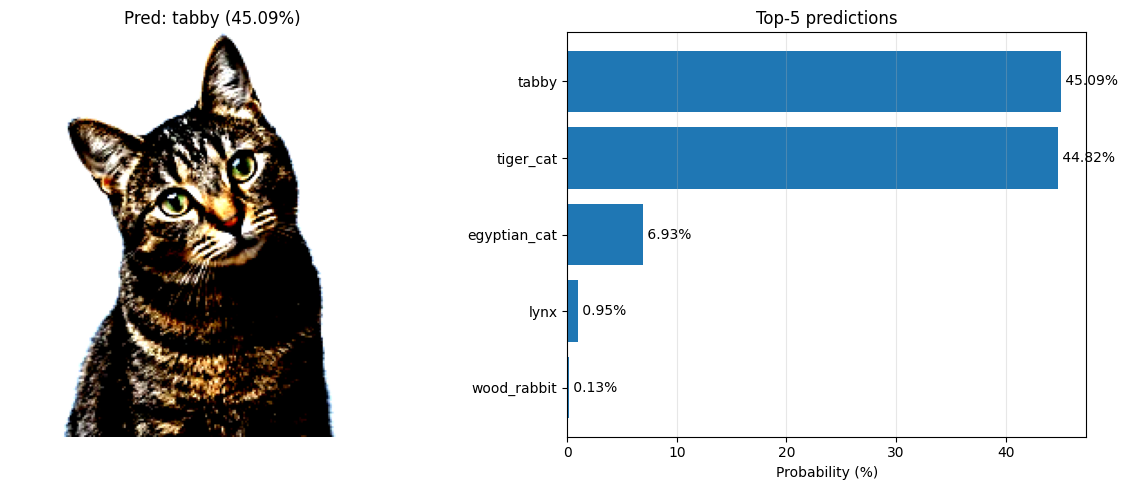

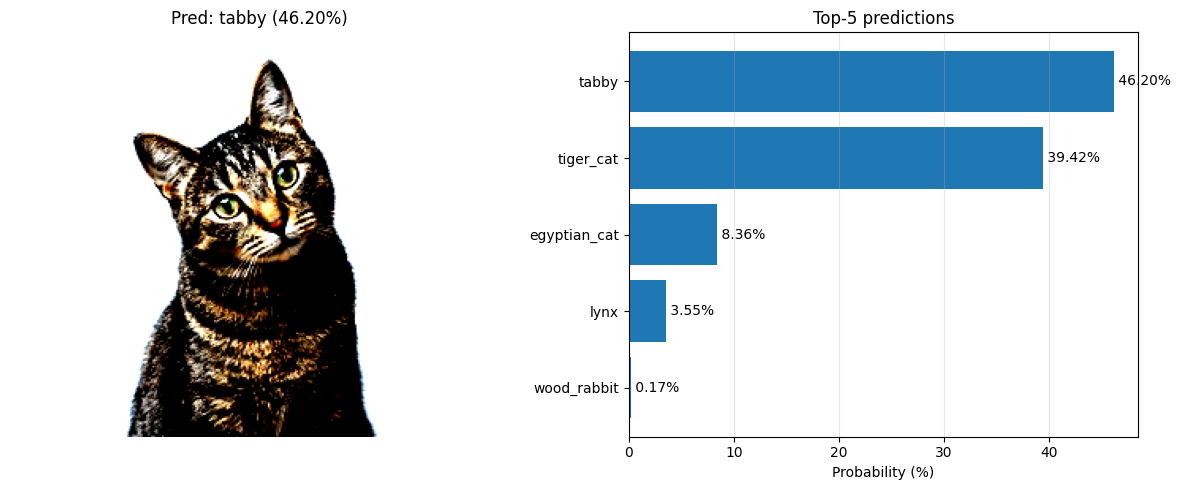

In [15]:
for transform in transforms:
    plot_image_prediction(
        model=model_0,
        image_path="cat.webp",
        transform=transform,
        class_names=class_names,
        device=device
    )

In [16]:
pip install gradio

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
from typing import Dict, Tuple

import gradio as gr
import torch
from PIL import Image
from torch import nn
from torchvision import transforms
from torchvision.transforms import InterpolationMode

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = Path("v1_224_continued_best_effnetb0_replica.pth")

def load_model() -> nn.Module:
	model = ReplicaEffNetB0(
		num_classes=num_classes
	).to(device)

	checkpoint = torch.load(
		MODEL_PATH,
		map_location=device
	)

	model.load_state_dict(checkpoint["model_state_dict"])
	model.eval()

	print(f"Loaded checkpoint from: {MODEL_PATH}")

	if "epoch" in checkpoint:
		print(f"Epoch: {checkpoint['epoch']}")

	if "test_acc" in checkpoint:
		print(f"Test acc: {checkpoint['test_acc']:.4f}")

	if "test_loss" in checkpoint:
		print(f"Test loss: {checkpoint['test_loss']:.4f}")

	return model


model_0 = load_model()


def probs_to_predictions(
	probs: torch.Tensor,
	top_k: int = 5
) -> Dict[str, float]:
	top_probs, top_indices = torch.topk(
		probs,
		k=min(top_k, len(class_names))
	)

	predictions = {}

	for prob, index in zip(top_probs, top_indices):
		class_name = class_names[index.item()]
		predictions[class_name] = float(prob.item())

	return predictions


def get_probs(
	image: Image.Image,
	transform: transforms.Compose
) -> torch.Tensor:
	image_tensor = transform(image).unsqueeze(dim=0).to(device)

	with torch.inference_mode():
		logits = model_0(image_tensor)
		probs = torch.softmax(logits, dim=1).squeeze(dim=0)

	return probs


def predict(
	image: Image.Image
) -> Tuple[Dict[str, float], Dict[str, float], Dict[str, float]]:
	if image is None:
		return {}, {}, {}

	image = image.convert("RGB")

	# 128 inference
	probs_128 = get_probs(
		image=image,
		transform=test_transform
	)

	# 224 TTA inference
	probs_224_1 = get_probs(
		image=image,
		transform=v1_test_transform
	)

	probs_224_2 = get_probs(
		image=image,
		transform=v2_test_transform
	)

	probs_224 = torch.stack(
		[probs_224_1, probs_224_2],
		dim=0
	).mean(dim=0)

	# Average 128 + 224
	probs_avg = torch.stack(
		[probs_128, probs_224],
		dim=0
	).mean(dim=0)

	pred_128 = probs_to_predictions(probs_128)
	pred_224 = probs_to_predictions(probs_224)
	pred_avg = probs_to_predictions(probs_avg)

	return pred_128, pred_224, pred_avg


demo = gr.Interface(
	fn=predict,
	inputs=gr.Image(
		type="pil",
		label="Upload animal image"
	),
	outputs=[
		gr.Label(
			num_top_classes=5,
			label="Prediction 128x128"
		),
		gr.Label(
			num_top_classes=5,
			label="Prediction 224x224"
		),
		gr.Label(
			num_top_classes=5,
			label="Prediction 224x224 no Center Crop"
		)
	],
	title="Animal Classifier",
	description=" "
)

demo.launch(
	share=True,
	debug=True
)

Loaded checkpoint from: v1_224_continued_best_effnetb0_replica.pth
Epoch: 17
Test acc: 0.7480
Test loss: 1.4814
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6df172640d10a942bd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Created dataset file at: .gradio/flagged/dataset2.csv
